In [15]:
# ========= 1、导入库 + 登录 BaoStock =========

import baostock as bs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # 忽略警告

plt.rcParams['font.sans-serif'] = ['SimHei']   # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False      # 正常显示负号

# 登录 BaoStock（无需注册）
lg = bs.login()
print(f"登录状态: {lg.error_code} - {lg.error_msg}")

login success!
登录状态: 0 - success


In [12]:
# ========= 2、获取沪深300成分股 =========

# 获取沪深300成分股列表
rs = bs.query_hs300_stocks()
hs300 = rs.get_data()
print(f"共获取 {len(hs300)} 只成分股")
print(hs300.head())

# 取前50只，减少数据量
stock_list = hs300['code'].tolist()[:50]  # stock_list是前50支股票的股票代码组成的列表
print(stock_list[:10])

共获取 300 只成分股
   updateDate       code code_name
0  2026-09-14  sh.600000      浦发银行
1  2026-09-14  sh.600009      上海机场
2  2026-09-14  sh.600010      包钢股份
3  2026-09-14  sh.600011      华能国际
4  2026-09-14  sh.600015      华夏银行
['sh.600000', 'sh.600009', 'sh.600010', 'sh.600011', 'sh.600015', 'sh.600016', 'sh.600018', 'sh.600019', 'sh.600023', 'sh.600025']


In [13]:
# ========= 3、获取个股日线数据 =========

# 获取50只股票2023-2024年的日线数据
all_data = []

for code in stock_list:
    rs = bs.query_history_k_data_plus(
        code,
        "date,code,close,volume",
        start_date='2023-01-01',
        end_date='2024-12-31',
        frequency="d",
        adjustflag="2"  # 前复权（把历史价格调整到和当前价格同一口径，避免分红送股造成的假暴跌，让回测结果真实可信）
    )
    df = rs.get_data()
    if len(df) > 0:  # 条件判断：如果这个表格不是空的
        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)
data['date'] = pd.to_datetime(data['date'])
data['close'] = data['close'].astype(float)
data = data.sort_values(['code', 'date'])
print(f"总数据量: {len(data)} 行")
print(data.head())

总数据量: 24200 行
        date       code     close    volume
0 2023-01-03  sh.600000  6.184694  25892521
1 2023-01-04  sh.600000  6.253128  30947081
2 2023-01-05  sh.600000  6.287344  30162154
3 2023-01-06  sh.600000  6.278790  20312881
4 2023-01-09  sh.600000  6.278790  19612260


In [6]:
# ========= 4、计算反转因子 =========

# 计算过去20日收益率
data['ret_20d'] = data.groupby('code')['close'].pct_change(20)

# 反转因子 = 负的20日收益率（过去跌得多的，因子值大）
data['reversal_factor'] = -data['ret_20d']

# 计算未来5日收益率（用于评估因子效果）
data['forward_ret_5d'] = data.groupby('code')['close'].pct_change(5).shift(-5)

# 去掉缺失值
factor_data = data.dropna(subset=['reversal_factor', 'forward_ret_5d']).copy()
print(f"有效数据量: {len(factor_data)} 行")

有效数据量: 22950 行


In [7]:
# ========= 5、分组回测 =========

# 每个交易日，按因子值将股票分为5组
factor_data['group'] = factor_data.groupby('date')['reversal_factor'].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates='drop')
)

# 计算各组未来5日平均收益
group_ret = factor_data.groupby(['date', 'group'])['forward_ret_5d'].mean().unstack()

# 计算各组累计净值
group_nav = (1 + group_ret).cumprod()

# 多空组合：做多第5组（因子值最高），做空第1组
group_ret['long_short'] = group_ret[4] - group_ret[0]
ls_nav = (1 + group_ret['long_short']).cumprod()

print("分组回测完成")
print(group_nav.tail())

分组回测完成
group              0         1         2         3         4
date                                                        
2024-12-18  3.195863  2.296125  1.628020  1.107470  2.447229
2024-12-19  3.216094  2.285235  1.639719  1.103797  2.442905
2024-12-20  3.208440  2.315163  1.678561  1.114324  2.455361
2024-12-23  3.226939  2.336294  1.678987  1.123514  2.507345
2024-12-24  3.153177  2.292409  1.640681  1.118486  2.461247


In [8]:
# ========= 6、计算IC值 =========

# 每个交易日计算一次IC
ic_series = factor_data.groupby('date').apply(
    lambda x: x['reversal_factor'].corr(x['forward_ret_5d'])
)

print(f"IC均值: {ic_series.mean():.4f}")
print(f"IC标准差: {ic_series.std():.4f}")
print(f"ICIR: {ic_series.mean()/ic_series.std():.4f}")

IC均值: 0.0135
IC标准差: 0.2417
ICIR: 0.0557


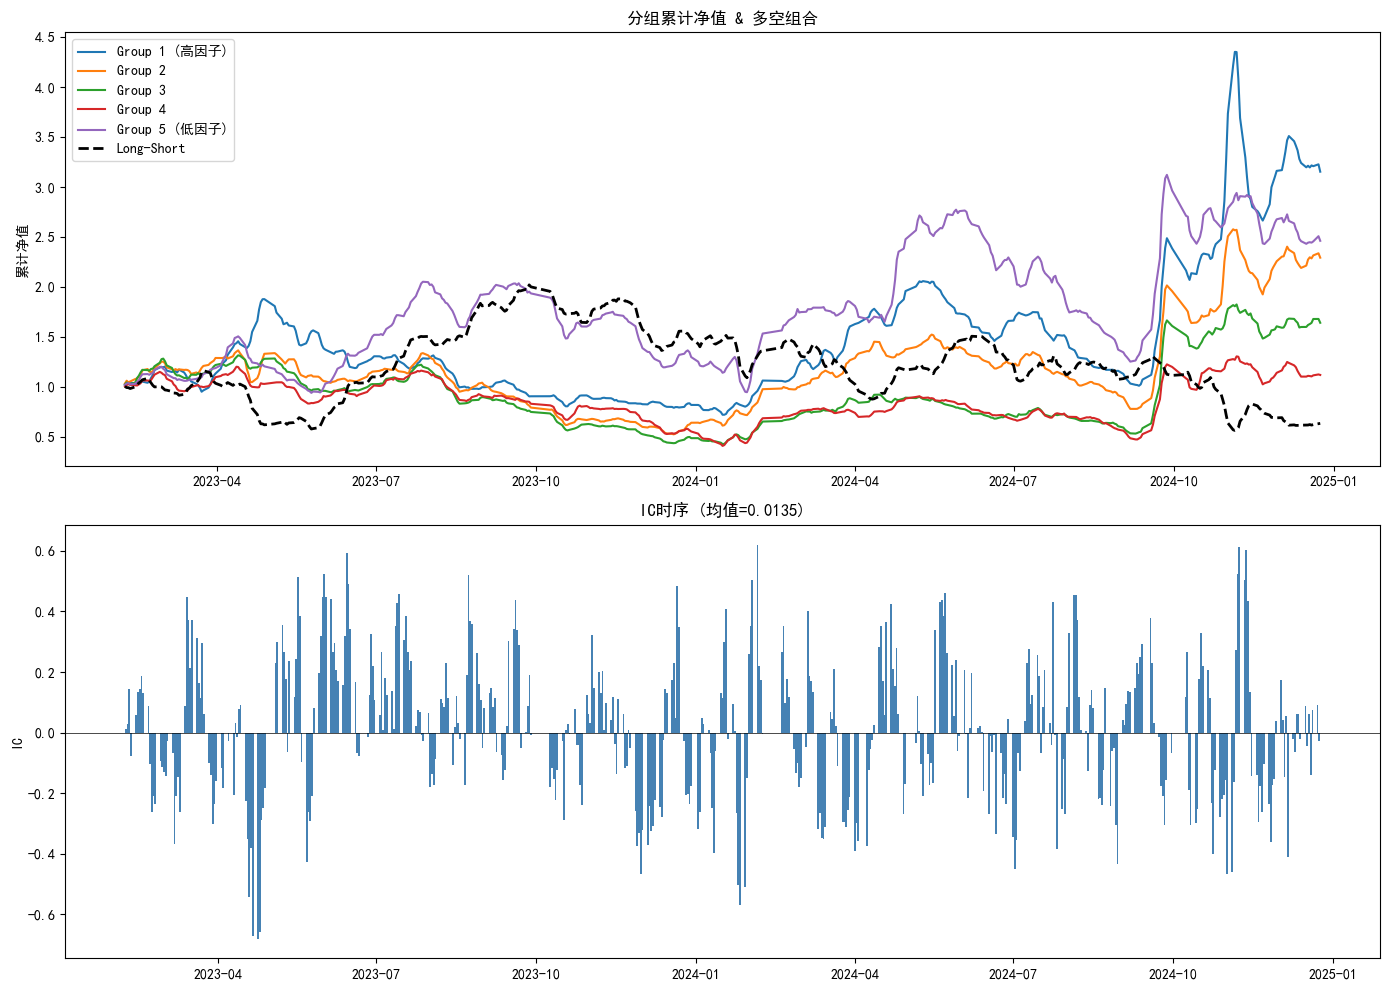

IC均值: 0.0135
ICIR: 0.0557
多空组合年化收益: -22.17%
多空组合最大回撤: -72.14%


In [16]:
# ========= 7、画图 + 输出结果 =========

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 分组累计净值
for g in range(5):
    label = f'Group {g+1}'
    if g == 0:
        label += ' (高因子)'
    elif g == 4:
        label += ' (低因子)'
    axes[0].plot(group_nav.index, group_nav[g], label=label)
axes[0].plot(ls_nav.index, ls_nav, label='Long-Short', linewidth=2, linestyle='--', color='black')
axes[0].legend()
axes[0].set_title('分组累计净值 & 多空组合')
axes[0].set_ylabel('累计净值')

# IC时序
axes[1].bar(ic_series.index, ic_series.values, width=1, color='steelblue')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_title(f'IC时序 (均值={ic_series.mean():.4f})')
axes[1].set_ylabel('IC')

plt.tight_layout()
plt.savefig('factor_report.png', dpi=150)
plt.show()

# 打印关键指标
print("=" * 50)
print(f"IC均值: {ic_series.mean():.4f}")
print(f"ICIR: {ic_series.mean()/ic_series.std():.4f}")
print(f"多空组合年化收益: {(ls_nav.iloc[-1]**(252/len(ls_nav))-1)*100:.2f}%")
print(f"多空组合最大回撤: {(ls_nav/ls_nav.cummax()-1).min()*100:.2f}%")
print("=" * 50)

In [10]:
# ========= 8、登出 =========

bs.logout()
print("BaoStock已登出")

logout success!
BaoStock已登出


步骤：
使用BaoStock获取沪深300前50只成分股2023-2024年日频数据，用Python（pandas/numpy）计算20日反转因子
按因子值分5组回测，IC均值0.0135，ICIR 0.0557，多头组（高因子）累计净值3.2倍，多空组累计净值0.8倍

结论：
发现因子多头端有效，但空头端在2024年Q4普涨行情中大幅回撤，空头端失效，多空组合亏损，说明空头端在普涨行情里会失灵，验证了反转因子对市场环境的敏感性
IC均值0.0135，说明因子方向正确但预测力弱且不稳定